In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from matplotlib import pyplot as plt

In [ ]:
def calculate_p_up(s_zero, s_t, time_elapsed, volatility):
    threshold = np.log(s_zero/s_t)
    time_left = 900 - time_elapsed
    if time_left <= 0:
        return 0
    p_up = 1 - norm.cdf(threshold / (volatility * np.sqrt(time_left)))
    return p_up

def calculate_ev_up(ask_up, fee, p_up):
    return (1-fee-ask_up)*p_up - (ask_up)*(1-p_up)

def calculate_ev_down(bid_up, fee, p_up):
    ask_down = 1 - bid_up
    return (1-fee-ask_down)*(1-p_up) - (ask_down)*p_up

def kelly_fraction_up(ask_up, fee, p_up):
    b = (1-fee-ask_up)/ask_up
    return p_up - (1-p_up)/b

def kelly_fraction_down(bid_up, fee, p_up):
    ask_down = 1 - bid_up
    b = (1-fee-ask_down)/(ask_down)
    return (1-p_up) - p_up/b

print(calculate_ev_up(0.6, 0.01, 0.7))
print(calculate_ev_down(0.4, 0.01, 0.3))
print(kelly_fraction_up(0.6, 0.01, 0.7))
print(kelly_fraction_down(0.4, 0.01, 0.3))

0.15499999999999992
0.15499999999999997
0.2384615384615384
0.23846153846153845


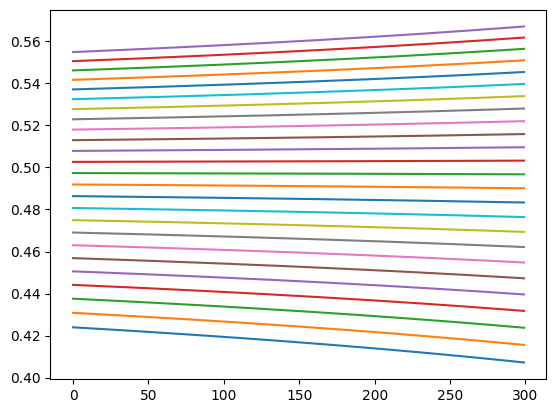

In [3]:
for i in range(25):
    x = np.array([])
    for j in range(300):
        x = np.append(x, calculate_p_up(100, i*2+75, j, 0.05))
    plt.plot(x)

In [ ]:
import glob
import os
import re

# Automatically discover all reconstructed orderbook files and extract timestamps
data_dir = 'data'
reconstructed_files = sorted(glob.glob(os.path.join(data_dir, 'orderbook_*_reconstructed.csv')))

# Extract timestamps from filenames
timestamps = []
for f in reconstructed_files:
    match = re.search(r'orderbook_(\d+)_reconstructed\.csv', os.path.basename(f))
    if match:
        timestamps.append(int(match.group(1)))

timestamps = sorted(set(timestamps))
print(f"Found {len(timestamps)} reconstructed timestamp(s): {timestamps}\n")

# Load data for all timestamps
all_data = {}

for timestamp in timestamps:
    timestamp_str = str(timestamp)
    
    # Load reconstructed orderbook file
    try:
        btc_orderbook = pd.read_csv(os.path.join(data_dir, f'orderbook_{timestamp_str}_reconstructed.csv'))
        print(f"Loaded: orderbook_{timestamp_str}_reconstructed.csv ({len(btc_orderbook)} records)")
    except FileNotFoundError as e:
        print(f"Error loading orderbook for {timestamp}: {e}")
        continue
    
    # Load threshold and coinbase price files
    try:
        btc_threshold = pd.read_csv(os.path.join(data_dir, f'threshold_{timestamp_str}.csv'))
        btc_price_coinbase = pd.read_csv(os.path.join(data_dir, f'btc_coinbase_{timestamp_str}.csv'))
        print(f"  threshold: {len(btc_threshold)} record(s)")
        print(f"  coinbase price: {len(btc_price_coinbase)} record(s)\n")
    except FileNotFoundError as e:
        print(f"Error loading supporting files for {timestamp}: {e}")
        continue
    
    # Store data for this timestamp
    all_data[timestamp] = {
        'orderbook': btc_orderbook,
        'threshold': btc_threshold,
        'price_coinbase': btc_price_coinbase,
    }

print(f"Successfully loaded data for {len(all_data)} timestamp(s)")

In [5]:
# Combine threshold (from Kalshi), coinbase price, best_yes_ask, best_yes_bid, and yes_depth_3 into single dataframe
# Use orderbook timestamps as the primary index

trade_data_all = {}

print(f"Processing {len(all_data)} period(s)...\n")

for period, data in all_data.items():
    btc_orderbook = data['orderbook']
    btc_threshold = data['threshold']
    btc_price_coinbase = data['price_coinbase']
    
    print(f"Period {period}:")
    print(f"  Orderbook shape: {btc_orderbook.shape}")
    print(f"  Threshold shape: {btc_threshold.shape}")
    print(f"  Coinbase price shape: {btc_price_coinbase.shape}")
    
    # Create combined dataframe using orderbook timestamps as the base
    # For Kalshi: best_yes_ask is the asking price (best_ask), best_yes_bid is the bidding price (best_bid)
    trade_data = btc_orderbook[['timestamp_utc', 'best_yes_ask', 'best_yes_bid', 'yes_depth_3']].copy()
    trade_data = trade_data.rename(columns={
        'timestamp_utc': 'time',
        'best_yes_ask': 'best_ask',
        'best_yes_bid': 'best_bid'
    })
    
    # Add threshold_price from Kalshi (single value for the 15-minute window)
    if len(btc_threshold) > 0:
        trade_data['s0_price'] = btc_threshold['threshold_price'].iloc[0]
        print(f"  Threshold price: {btc_threshold['threshold_price'].iloc[0]:.2f}")
    else:
        print(f"  No threshold data - skipping")
        continue  # Skip if no threshold data
    
    # Convert timestamp to datetime for merging
    trade_data['time'] = pd.to_datetime(trade_data['time'])
    
    # Add coinbase price by forward-filling from coinbase data
    btc_price_coinbase['received_at_utc'] = pd.to_datetime(btc_price_coinbase['received_at_utc'])
    btc_price_sorted = btc_price_coinbase.sort_values('received_at_utc').reset_index(drop=True)
    
    trade_data['coinbase_price'] = pd.merge_asof(
        trade_data,
        btc_price_sorted[['received_at_utc', 'price']].rename(columns={'received_at_utc': 'time'}),
        on='time',
        direction='backward'
    )['price']
    
    trade_data_all[period] = trade_data
    print(f"  Trade data shape: {trade_data.shape}")
    print(f"  Missing coinbase prices: {trade_data['coinbase_price'].isna().sum()}\n")

print(f"\nCombined trade data for {len(trade_data_all)} period(s)")
print(f"Periods in trade_data_all: {sorted(trade_data_all.keys())}")

Processing 2 period(s)...

Period 1779933600:
  Orderbook shape: (5878, 13)
  Threshold shape: (1, 5)
  Coinbase price shape: (222, 4)
  Threshold price: 74219.20
  Trade data shape: (5878, 6)
  Missing coinbase prices: 34

Period 1779934500:
  Orderbook shape: (112890, 13)
  Threshold shape: (1, 5)
  Coinbase price shape: (4078, 4)
  Threshold price: 74240.47
  Trade data shape: (112890, 6)
  Missing coinbase prices: 2


Combined trade data for 2 period(s)
Periods in trade_data_all: [1779933600, 1779934500]


In [6]:
# Calculate volatility using Kalshi coinbase prices and p_up
# Volatility is calculated from coinbase prices within the window
# Threshold (s0_price) comes from Kalshi's threshold file
results_all = {}

for period, trade_data in trade_data_all.items():
    btc_price_coinbase = all_data[period]['price_coinbase'].copy()

    # Aggregate btc_price_coinbase into 0.25-second bars for volatility
    btc_price_coinbase['received_at_utc'] = pd.to_datetime(btc_price_coinbase['received_at_utc'])
    btc_price_agg = btc_price_coinbase.set_index('received_at_utc').resample('0.25s')['price'].last().dropna()
    
    # Calculate returns from aggregated prices
    returns = np.array(np.log(btc_price_agg / btc_price_agg.shift(1)))
    returns[0] = 0
    vol = np.std(returns)

    best_ask = np.array(trade_data['best_ask'])
    best_bid = np.array(trade_data['best_bid'])
    s0_price = np.array(trade_data['s0_price'])
    coinbase_price = np.array(trade_data['coinbase_price'])
    yes_depth_3 = np.array(trade_data['yes_depth_3'])
    
    # Calibrate coinbase_price to s0_price
    if not np.isnan(coinbase_price[~np.isnan(coinbase_price)][0]):
        price_calibrated = coinbase_price[~np.isnan(coinbase_price)][0] - s0_price[0]
        coinbase_price = coinbase_price - price_calibrated

    time_elapsed = np.array((trade_data['time'] - trade_data['time'].iloc[0]).dt.total_seconds())
    print(f'Period {period} - vol:{vol:.8f}')
    
    # Calculate p_up for each time point using coinbase price
    p_up = np.array([])
    for i in range(len(trade_data)):
        p_up = np.append(p_up, calculate_p_up(s0_price[i], coinbase_price[i], time_elapsed[i], vol))

    results_all[period] = {
        'vol': vol,
        'best_ask': best_ask,
        'best_bid': best_bid,
        's0_price': s0_price,
        'coinbase_price': coinbase_price,
        'time_elapsed': time_elapsed,
        'p_up': p_up,
        'yes_depth_3': yes_depth_3
    }

print(f"\nCalculated results for {len(results_all)} period(s)")

Period 1779933600 - vol:0.00003182
Period 1779934500 - vol:0.00003973

Calculated results for 2 period(s)


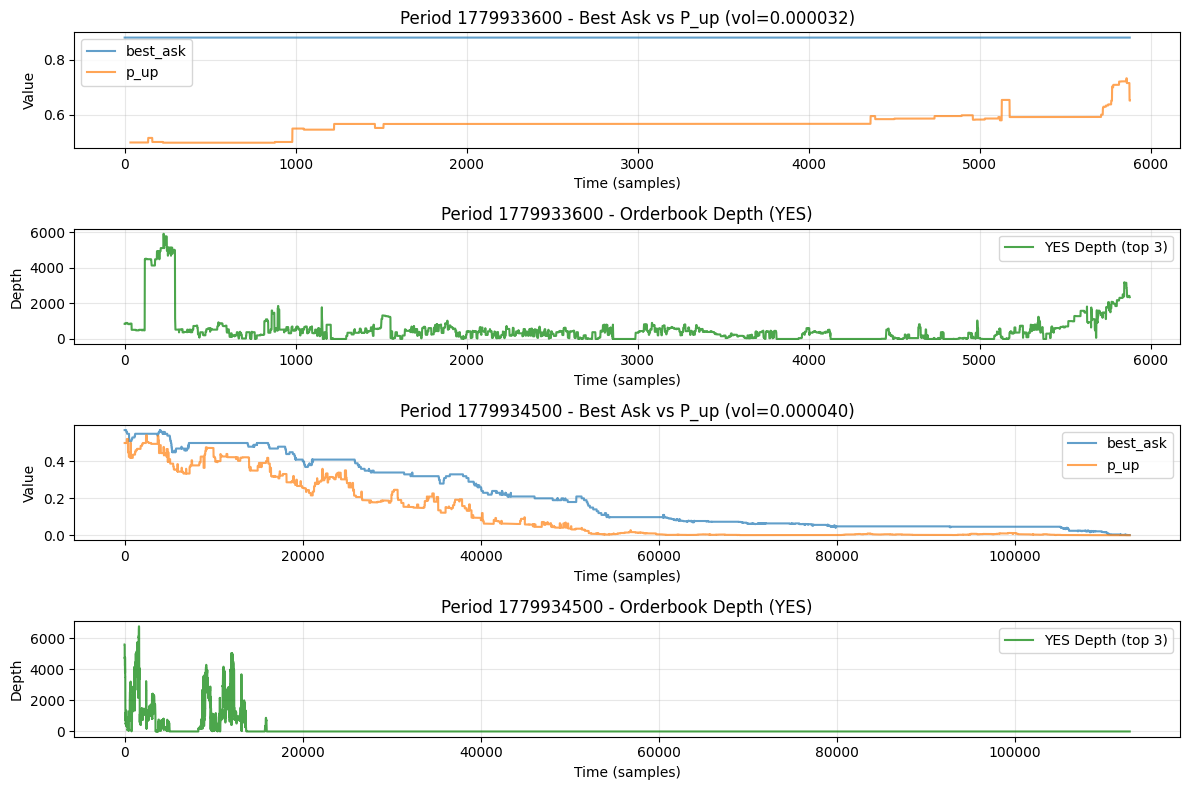

In [7]:
# Plot best_ask, p_up, and yes_depth_3 for all periods
num_periods = len(results_all)
fig, axes = plt.subplots(num_periods*2, 1, figsize=(12, 4*num_periods))

# Handle axes array properly
if num_periods == 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
elif num_periods > 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else axes

for idx, (period, results) in enumerate(sorted(results_all.items())):
    # Top row: best_ask and p_up
    ax_top = axes[idx*2]
    best_ask = results['best_ask']
    p_up = results['p_up']
    
    ax_top.plot(best_ask, label='best_ask', alpha=0.7, linewidth=1.5)
    ax_top.plot(p_up, label='p_up', alpha=0.7, linewidth=1.5)
    ax_top.set_title(f'Period {period} - Best Ask vs P_up (vol={results["vol"]:.6f})')
    ax_top.set_xlabel('Time (samples)')
    ax_top.set_ylabel('Value')
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)
    
    # Bottom row: orderbook depth (yes_depth_3)
    ax_bottom = axes[idx*2+1]
    yes_depth_3 = results['yes_depth_3']
    
    ax_bottom.plot(yes_depth_3, label='YES Depth (top 3)', alpha=0.7, linewidth=1.5, color='green')
    ax_bottom.set_title(f'Period {period} - Orderbook Depth (YES)')
    ax_bottom.set_xlabel('Time (samples)')
    ax_bottom.set_ylabel('Depth')
    ax_bottom.legend()
    ax_bottom.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

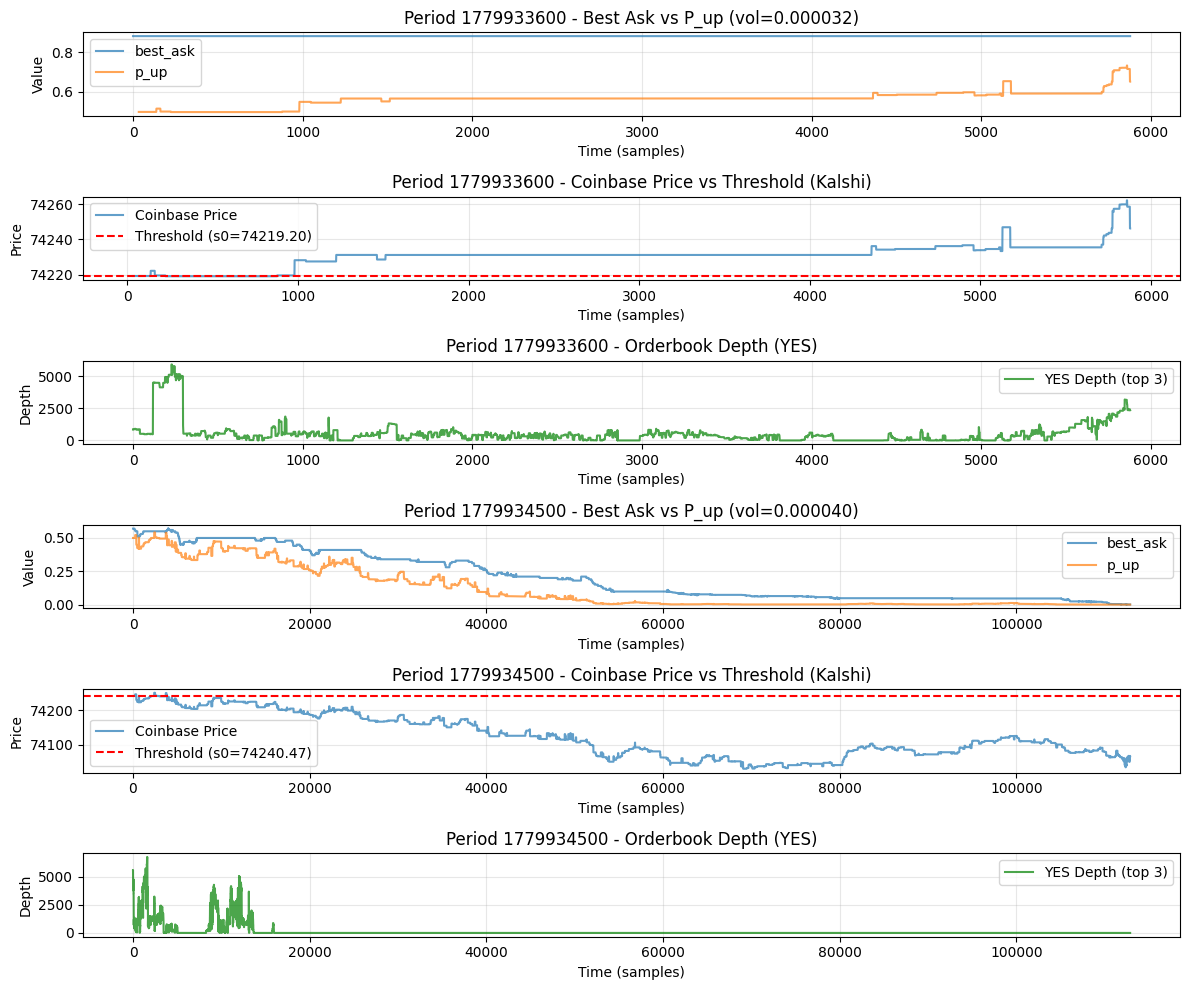

In [12]:
# Plot best_ask/p_up, coinbase_price/threshold, and yes_depth_3 for each period (3 rows per period)
num_periods = len(results_all)
fig, axes = plt.subplots(num_periods*3, 1, figsize=(12, 5*num_periods))

# Handle axes array properly
if num_periods == 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else axes
elif num_periods > 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else axes

for idx, (period, results) in enumerate(sorted(results_all.items())):
    # First row: best_ask and p_up
    ax1 = axes[idx*3]
    best_ask = results['best_ask']
    p_up = results['p_up']
    
    ax1.plot(best_ask, label='best_ask', alpha=0.7, linewidth=1.5)
    ax1.plot(p_up, label='p_up', alpha=0.7, linewidth=1.5)
    ax1.set_title(f'Period {period} - Best Ask vs P_up (vol={results["vol"]:.6f})')
    ax1.set_xlabel('Time (samples)')
    ax1.set_ylabel('Value')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Second row: coinbase_price and threshold
    ax2 = axes[idx*3+1]
    coinbase_price = results['coinbase_price']
    s0_price = results['s0_price'][0]
    
    ax2.plot(coinbase_price, label='Coinbase Price', alpha=0.7, linewidth=1.5)
    ax2.axhline(y=s0_price, color='r', linestyle='--', label=f'Threshold (s0={s0_price:.2f})', linewidth=1.5)
    ax2.set_title(f'Period {period} - Coinbase Price vs Threshold (Kalshi)')
    ax2.set_xlabel('Time (samples)')
    ax2.set_ylabel('Price')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Third row: orderbook depth (yes_depth_3)
    ax3 = axes[idx*3+2]
    yes_depth_3 = results['yes_depth_3']
    
    ax3.plot(yes_depth_3, label='YES Depth (top 3)', alpha=0.7, linewidth=1.5, color='green')
    ax3.set_title(f'Period {period} - Orderbook Depth (YES)')
    ax3.set_xlabel('Time (samples)')
    ax3.set_ylabel('Depth')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

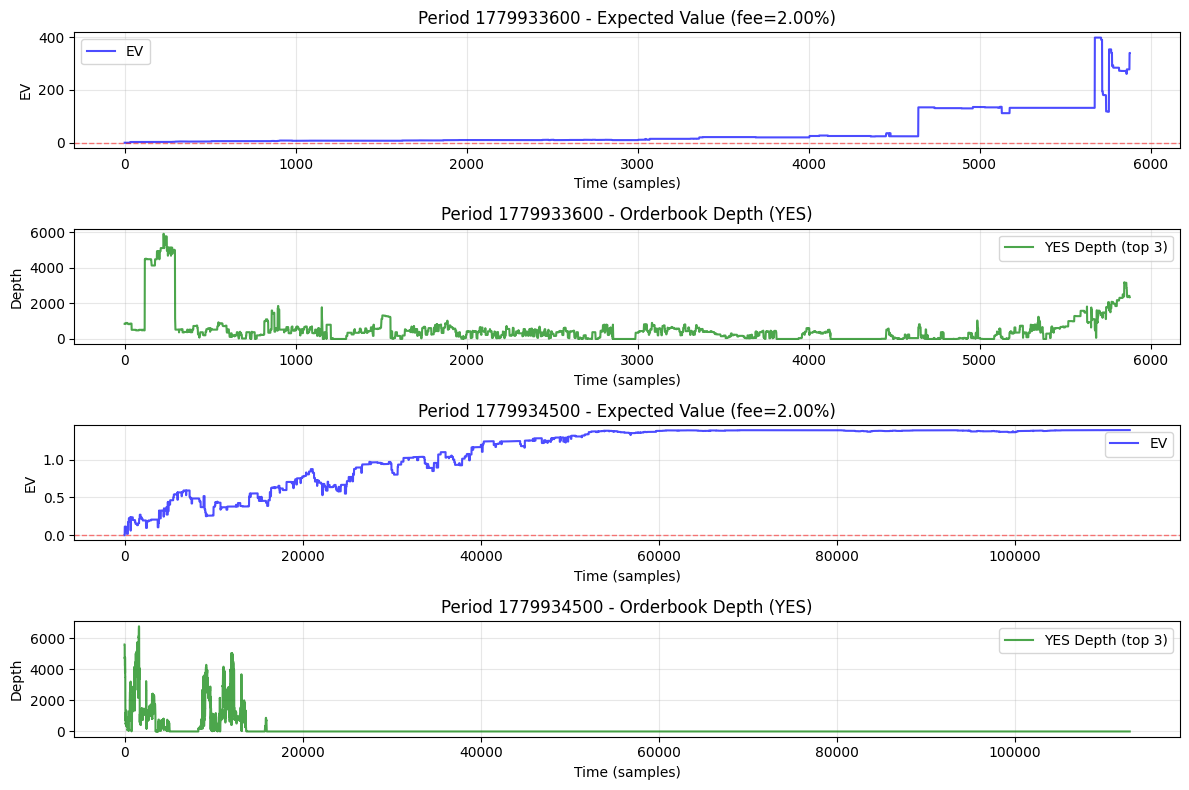

In [9]:
# Calculate and plot expected value (EV) and orderbook depth for each period
fee = 0.02  # 2% trading fee

num_periods = len(results_all)
fig, axes = plt.subplots(num_periods*2, 1, figsize=(12, 4*num_periods))

# Handle axes array properly
if num_periods == 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
elif num_periods > 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else axes

for idx, (period, results) in enumerate(sorted(results_all.items())):
    # Top row: EV
    ax_top = axes[idx*2]
    p_up = results['p_up']
    ask = results['best_ask']
    bid = results['best_bid']
    
    # Calculate EV for each time point
    ev = np.zeros_like(p_up)
    
    for i in range(len(p_up)):
        # Check conditions for long and short
        long_threshold = ask[i] / (1 - fee)
        short_threshold = (bid[i] - fee) / (1 - fee)
        
        if p_up[i] > long_threshold:
            ev[i] = calculate_ev_up(ask[i], fee, p_up[i])
        elif p_up[i] < short_threshold:
            ev[i] = calculate_ev_down(bid[i], fee, p_up[i])
        else:
            ev[i] = 0
    
    ax_top.plot(ev, label='EV', alpha=0.7, linewidth=1.5, color='blue')
    ax_top.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)
    ax_top.set_title(f'Period {period} - Expected Value (fee={fee:.2%})')
    ax_top.set_xlabel('Time (samples)')
    ax_top.set_ylabel('EV')
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)
    
    # Bottom row: orderbook depth
    ax_bottom = axes[idx*2+1]
    yes_depth_3 = results['yes_depth_3']
    
    ax_bottom.plot(yes_depth_3, label='YES Depth (top 3)', alpha=0.7, linewidth=1.5, color='green')
    ax_bottom.set_title(f'Period {period} - Orderbook Depth (YES)')
    ax_bottom.set_xlabel('Time (samples)')
    ax_bottom.set_ylabel('Depth')
    ax_bottom.legend()
    ax_bottom.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

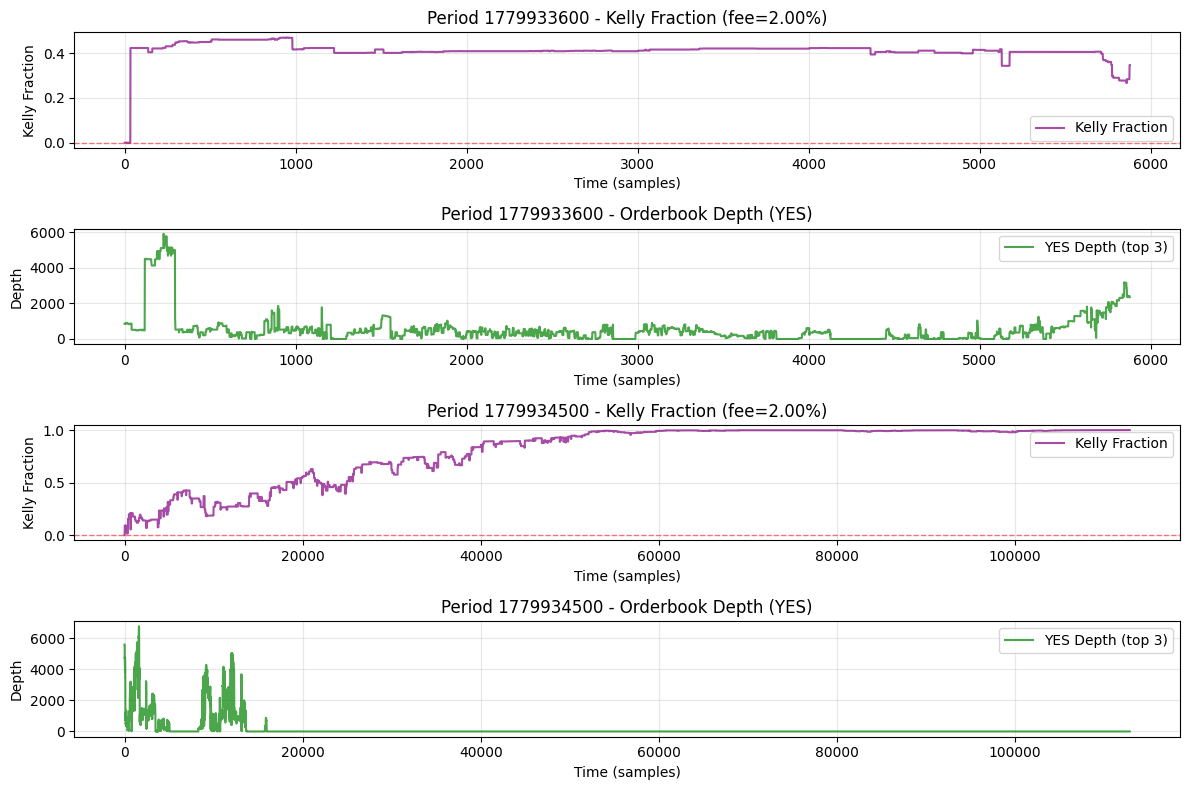

In [10]:
# Calculate and plot Kelly fraction and orderbook depth for each period
fee = 0.02  # 2% trading fee

num_periods = len(results_all)
fig, axes = plt.subplots(num_periods*2, 1, figsize=(12, 4*num_periods))

# Handle axes array properly
if num_periods == 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
elif num_periods > 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else axes

for idx, (period, results) in enumerate(sorted(results_all.items())):
    # Top row: Kelly fraction
    ax_top = axes[idx*2]
    p_up = results['p_up']
    ask = results['best_ask']
    bid = results['best_bid']
    
    # Calculate Kelly fraction for each time point
    k_fraction = np.zeros_like(p_up)
    
    for i in range(len(p_up)):
        # Check conditions for long and short
        long_threshold = ask[i] / (1 - fee)
        short_threshold = (bid[i] - fee) / (1 - fee)
        
        if p_up[i] > long_threshold:
            k_fraction[i] = kelly_fraction_up(ask[i], fee, p_up[i])
        elif p_up[i] < short_threshold:
            k_fraction[i] = kelly_fraction_down(bid[i], fee, p_up[i])
        else:
            k_fraction[i] = 0
    
    ax_top.plot(k_fraction, label='Kelly Fraction', alpha=0.7, linewidth=1.5, color='purple')
    ax_top.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)
    ax_top.set_title(f'Period {period} - Kelly Fraction (fee={fee:.2%})')
    ax_top.set_xlabel('Time (samples)')
    ax_top.set_ylabel('Kelly Fraction')
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)
    
    # Bottom row: orderbook depth
    ax_bottom = axes[idx*2+1]
    yes_depth_3 = results['yes_depth_3']
    
    ax_bottom.plot(yes_depth_3, label='YES Depth (top 3)', alpha=0.7, linewidth=1.5, color='green')
    ax_bottom.set_title(f'Period {period} - Orderbook Depth (YES)')
    ax_bottom.set_xlabel('Time (samples)')
    ax_bottom.set_ylabel('Depth')
    ax_bottom.legend()
    ax_bottom.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

0.012801391342696589
0.01626160404127143


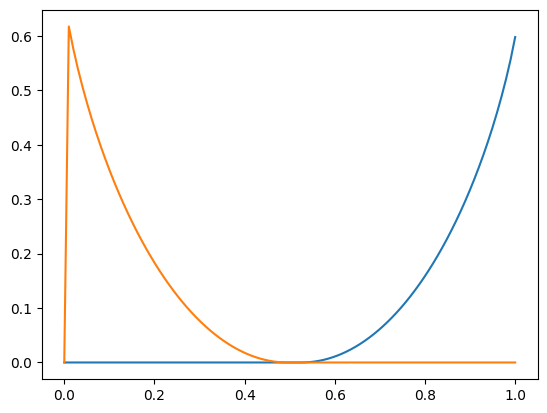

In [11]:
def calc_growth_up(p_up, bid_up, ask_up, fee):
    k_fraction = kelly_fraction_up(ask_up, fee, p_up)
    if k_fraction < 0:
        return 0
    b = (1 - fee - ask_up) / ask_up
    G = p_up * (np.log(1+(b*k_fraction))) + (1-p_up) * (np.log(1-k_fraction))
    return G

def calc_growth_down(p_up, bid_up, ask_up, fee):
    k_fraction = kelly_fraction_down(bid_up, fee, p_up)
    if k_fraction < 0:
        return 0
    ask_down = 1 - bid_up
    b = (1 - fee - ask_down) / ask_down
    G = (1-p_up) * (np.log(1+(b*k_fraction))) + p_up * (np.log(1-k_fraction))
    return G

print(calc_growth_up(0.6, 0.5, 0.51, 0.02))
print(calc_growth_down(0.4, 0.5, 0.51, 0.02))

growth_up = np.zeros_like(np.linspace(0, 1, 100))
growth_down = np.zeros_like(np.linspace(0, 1, 100))
for i in range(1,100):
    p = i/100
    growth_up[i] = calc_growth_up(p, 0.5, 0.51, 0.02)
    growth_down[i] = calc_growth_down(p, 0.5, 0.51, 0.02)
plt.plot(np.linspace(0, 1, 100), growth_up)
plt.plot(np.linspace(0, 1, 100), growth_down)